In [3]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


100.0%
100.0%
100.0%
100.0%


In [10]:
# CHECKLIST 1

print("Dataset size:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)


Dataset size: 60000
Image shape: torch.Size([1, 28, 28])


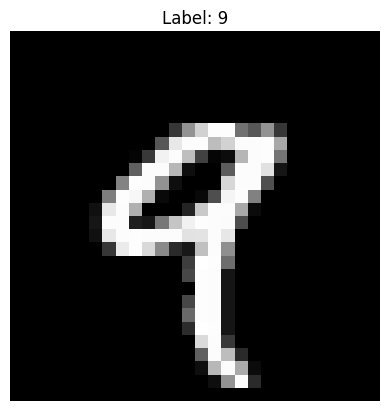

In [11]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")

plt.show()

In [12]:
# CHECKLIST 2

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [13]:

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64)

test_loader = DataLoader(test_dataset, batch_size=64)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [16]:
# CHECKLIST 3

import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)

        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

In [17]:
model = CNN()


In [18]:
images, labels = next(iter(train_loader))

output = model(images)

print(output.shape)

torch.Size([64, 10])
